In [20]:
#importing libraries
import numpy as np
import random
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import copy
import time

In [39]:
#configuring the graph display
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython: 
    from IPython import display

In [40]:
def main_program(iterations = 3, angle_step_size = 5, rows = 4, columns = 4, height = 4, given_model = None):
    
    if given_model is None:
        model = list()                         
        n_state, deformed_mat = material_state_init(angle_step_size, rows, columns, height)
        model.append([iterations, angle_step_size, [rows, columns, height]])
        total_energy = total_state_energy(n_state, deformed_mat)   
    
    else:  
        m_angle_step_size = given_model[0][1]     # model_present_angle_step_size
        assert (angle_step_size == m_angle_step_size),("Given step size, %d =/= model stored did not match, %d" 
                                                       %(angle_step_size, m_angle_step_size))
        assert rows == given_model[0][2][0], "Given number of rows, %d =/= model stored rows, %d " %(rows, model[0][2][0])
        assert columns == given_model[0][2][1], "Given number of columns, %d =/= model stored columns, %d" %(columns, model[0][2][1])
        assert height == given_model[0][2][2], "Given number of height, %d =/= model stored height, %d" %(height, model[0][2][2])
        
        n_state = given_model[-1][0]
        deformed_mat = given_model[-1][1]
        total_energy = given_model[-1][2]
        model = copy.deepcopy(given_model)
        model[0][0] = len(given_model) -1 + iterations
    
    #print("Initial Condition \n")
    
    #disp_im(n_state, total_energy, len(model)-1, 0)                 # len(model) = 1 ie energy_matrix
    for epoch in range(len(model), len(model) + iterations):      
        print("Iteration #", epoch, "\n")
        n_state, total_energy, deformed_mat = next_state(n_state, total_energy, deformed_mat, angle_step_size, epoch)
        model.append([n_state, deformed_mat, total_energy])       # model = 1st n_state, 2nd n_state, 3rd n_state,......
        disp_im(n_state, total_energy, epoch, 0)
    disp_im(n_state, total_energy, epoch, 0)      # change to 1 for rotable graph    
    return model

In [41]:
def material_state_init(angle_step_size, rows, columns, height):
    
    n_state = []                                                                      # angles = 0 to 90
    number_of_possible_angle_ori = np.floor((90-0)/angle_step_size)
    n_state = np.random.choice(range(0, 90+1, angle_step_size), size=(rows, columns, height, 3))
    #print(n_state, angle_step_size) # each lattice point has 3 euler angles
    # True Strain, ε = ln(L/Lo). Here, 96% total reduction happened. ε = ln(0.04Lo/Lo) = -3.218875825
    # Hi = (1e-7 * ε)/(2.2*ε + 1.1) * γ. Here, γ = 0.375 J/m^2, high angle gb energy
    # Hi = 0.2018010571e-7 J/m^2
        
    deformed_mat = np.ones((rows, columns, height)) * 0.2018010571e-7 # 0.2018e-7 / 9.375e-10 = 21.5
    return n_state, deformed_mat

In [42]:
def total_state_energy(n_state, deformed_mat):
    total_energy = 0
    rows = len(n_state)
    columns = len(n_state[0])
    height = len(n_state[0][0])
    for i in range(rows):
        for j in range(columns):
            for k in range(height):
                total_energy += complete_lattice_point_mis_ori_energy(n_state, i,j,k)  # grain boundary energy

    total_energy += np.sum(deformed_mat)
    return total_energy  

In [44]:
def disp_im(n_state, total_energy, i = 1, interactive = 0):  

    rows, columns, height, euler_angles = np.shape(n_state)
    data = np.ones((rows, columns, height), dtype=bool)
    
    if interactive == 0:
        %matplotlib inline
        
    else:
        %matplotlib widget
        #%matplotlib notebook
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    #ax = Axes3D(fig)
    # Voxels is used to customizations of the
    # sizes, positions and colors.
    #print("qw",total_energy)
    ax.set_title("Iteration: %d  Total Energy: %.2e" %(i, total_energy)) # %e for aEb, scientific notation numbers.Here,10 is written as e
    ax.voxels(data, facecolors=n_state/90)                               # plots 1x1x1 cubes of same colour, colour = RGB, 0 to 1 range
    plt.show()
    if is_ipython: 
        display.clear_output(wait=True)   # Make it false for quick execution
    #plt.imshow(n_state)
    #plt.show()
    plt.pause(1)

In [45]:
def next_state(n_state, total_energy, deformed_mat, angle_step_size, epoch):  # 1 Monte Carlo Step (MCS)
    
    n_state, deformed_mat = random_nucleation(n_state, deformed_mat, angle_step_size, epoch)
    total_energy = total_state_energy(n_state, deformed_mat)
    for i in range(int(len(n_state))):
        for j in range(int(len(n_state[0]))):
            for k in range(int(len(n_state[0][0]))):
                n_state, total_energy, deformed_mat = reori_attempt(n_state, total_energy, deformed_mat, i, j, k)
        print("current epoch is ", i+1,"/",int(len(n_state)), "th done", sep="")
    print("")    
    return n_state, total_energy, deformed_mat

In [46]:
def random_nucleation(n_state, deformed_mat, angle_step_size, epoch):
    
    r = len(n_state)
    c = len(n_state[0])
    h = len(n_state[0][0])
    
    k = np.cbrt(r*c*h)
    no_of_nucleations = int(k*np.exp(-epoch/np.sqrt(k)))     # nucleation rate
    if no_of_nucleations > 0:
        x = np.random.choice(range(0,r),no_of_nucleations)   # selects the pt's x,y,z whose ori will be changed
        y = np.random.choice(range(0,c),no_of_nucleations)
        z = np.random.choice(range(0,h),no_of_nucleations)

        # selects the new ori to give
        new_ori = np.random.choice(range(0, 90+1, angle_step_size), size=(no_of_nucleations,no_of_nucleations,no_of_nucleations, 3))
        #print(x,y,z)
        for i in range(len(x)):
            for j in range(len(y)):
                for k in range(len(z)):
                    n_state[x[i]][y[j]][z[k]] = new_ori[i][j][k]
                    deformed_mat[x[i]][y[j]][z[k]] = 0
    
    return n_state, deformed_mat

In [47]:
def reori_attempt(n_state, total_energy, deformed_mat, i, j, k):   
    
    rows = len(n_state)
    columns = len(n_state[0])
    height = len(n_state[0][0])

    new_ori = next_state_random_neighbour_ori_chosen(n_state, i,j,k)
    next_state = copy.deepcopy(n_state)
    next_state[i][j][k] = new_ori
    next_deformed_mat = copy.deepcopy(deformed_mat)
    next_deformed_mat[i][j][k] = 0
    
    old_pt_surr_energy = np.sum(deformed_mat)
    new_pt_surr_energy = np.sum(next_deformed_mat)
    
    for a in range(i-1, i+2):        # changing i,j,k ori changes the mis-ori energy between i-1,j,k and i,j,k when i-1,j,k is considered
        for b in range(j-1, j+2):
            for c in range(k-1, k+2):
                if a >= 0 and a < rows and b >= 0 and b < columns and c >= 0 and c < height:
                    old_pt_surr_energy += complete_lattice_point_mis_ori_energy(n_state, a,b,c)
                    new_pt_surr_energy += complete_lattice_point_mis_ori_energy(next_state, a,b,c)

    #old_pt_energy += complete_lattice_point_mis_ori_energy(n_state, i,j,k)
    #new_pt_energy += complete_lattice_point_mis_ori_energy(next_state, i,j,k)
    energy_diff = new_pt_surr_energy - old_pt_surr_energy
    #print(energy_diff)
    if energy_diff <= 0:
        next_state_total_energy = total_energy - old_pt_surr_energy + new_pt_surr_energy
        return next_state, next_state_total_energy, next_deformed_mat
    
    else:
        '''
        kT = 0.2
        p = np.random.uniform(0,1)
        if p < np.exp(-1* energy_diff/kT):     # meteropolis transition function
            next_state_total_energy = total_energy - old_pt_surr_energy + new_pt_surr_energy
            return next_state, next_state_total_energy
        else:
        '''
        return n_state, total_energy, deformed_mat       

In [48]:
def next_state_random_neighbour_ori_chosen(n_state, i,j,k):
    
    neighbours_ori = list()
    
    rows = len(n_state)
    columns = len(n_state[0])
    height = len(n_state[0][0])

    for a in range(i-1, i+2):
        for b in range(j-1, j+2):
            for c in range(k-1, k+2):
                if a >= 0 and a < rows and b >= 0 and b < columns and c >= 0 and c < height:
                    if a!= i or b!= j or c!= k:
                        neighbours_ori.append(n_state[a][b][c])
    
    new_ori = np.random.default_rng().choice(neighbours_ori, axis= 0)
    #print("qw", new_ori), # choosing an ori from the neighbour's ori list
    return new_ori

In [49]:
def complete_lattice_point_mis_ori_energy(n_state, i,j,k):      # considers all the 26 (3rd nearest) neighbours of pt (i,j,k)
    rows = len(n_state)                 
    columns = len(n_state[0])           #     (i-1,j-1,k)  (i-1,j,k)  (i-1,j+1,k)
    height = len(n_state[0][0])         #     (i,j-1,k)    (i,j,k)    (i,j+1,k)
                                        #    (i+1,j-1,k)  (i+1,j,k)  (i+1,j+1,k)      For k-1, k, k+1
    pt_mis_ori_energy = 0
    
    for a in range(i-1, i+2):
        for b in range(j-1, j+2):
            for c in range(k-1, k+2):
                if a >= 0 and a < rows and b >= 0 and b < columns and c >= 0 and c < height:
                    pt_mis_ori_energy += mis_ori_energy_between_two_neighbours(n_state[i][j][k], n_state[a][b][c])
                
    return pt_mis_ori_energy

In [50]:
def mis_ori_energy_between_two_neighbours(pt_i, pt_j):
    
    #print(pt_i,pt_j,len(pt_i),pt_i[0], type(pt_i))
    if np.array_equal(pt_i, pt_j):                  # if states identical, mis-ori energy = 0, kronecker delta function taken care
        return 0
    
    theta_ij = mis_ori_angle_calculator(pt_i, pt_j)
    #print(theta_ij,"qw")
    gamma_s = 0.375    # high angle gb energy (in joules/m^2)
    a = 0.05 * 1e-3    # average grain boundary (in m)
    theta_star = 15    # maximum value of low angle gb
    
    if theta_ij > theta_star:
        E_ij = gamma_s * a*a           # 9.375e-10
    else:
        E_ij = gamma_s * a*a * (theta_ij/theta_star) * (1 - np.log((theta_ij/theta_star)+1e-8))
            

    #print(A, theta_ij, E_ij)
    
    return E_ij

In [51]:
def mis_ori_angle_calculator(pt_i, pt_j):       
    phi_1i, phi_i, phi_2i = pt_i    # Assuming ZXZ Bunge system used
    phi_1j, phi_j, phi_2j = pt_j    
    
    # grain ori, g = R_phi2.R_phi.R_phi1
    g1 = np.dot(Rz(phi_2i), np.dot(Rx(phi_i), Rz(phi_1i)))
    g2 = np.dot(Rz(phi_2j), np.dot(Rx(phi_j), Rz(phi_1j)))
    
    O = symmetric_matrix_24()
    # O is all the 24 symm rot mat. O[0]'s inverse lies in O.'
    # mis_ori, 24* 3*3, delta_g = (O.g2).(O.g1)^-1 = O. g2.g1^-1 .O  
    # theta_24 = arccos((Trace(delta_g) -1)/2)
    
    g2_g1inv = np.dot(g2, np.linalg.inv(g1))
    delta_g = np.matmul(np.matmul(O, g2_g1inv), O)
    delta_g_trace = np.trace(delta_g,axis1=1, axis2=2)
    #print("t",delta_g_trace)
    theta_24 = np.arccos(np.round((delta_g_trace-1)/2,5))
    #print("all thetas",theta_24)
    theta = np.rad2deg(min(theta_24))
    return theta

In [52]:
def symmetric_matrix_24():
    # symmetric matrix (24 for cubic system). 
    '''
    There are 24 symmetry elements for a cube (We dont count inversion):
    the fourfold rotations about axes normal to the faces of the cube (i.e., 90° rotations about the 〈0 0 1〉 crystal directions),
        90°, 180°, 270° rotations about [100], [010], [001] are symmetric.            Net 3*3 = 9
    the twofold rotations about the face diagonals (180° rotations about 〈1 1 0〉),
        180° rotations about the [110], [101],  [011], [0 1- 1], [1 0 -1], [-1 1 0]   Net 1*6 = 6
    the threefold rotations about the body diagonals (120° about 〈1 1 1〉). 
        120°, 240° rotations about the [111], [1- 1 1], [1 1- 1], [1 1 1-].           Net 2*4 = 8
    the idetity symmetry.                                                             Net     = 1
                                                                                      Total = 24    
    '''
    O = list()  # to store all the 24 members of 432 symm group
    # Below 9 belong to three-fold axis of sym rotation
    O.append([[1,0,0], [0,1,0], [0,0,1]])   #Identity
    O.append([[0,0,1], [1,0,0], [0,1,0]])
    O.append([[0,1,0], [0,0,1], [1,0,0]])
    O.append([[0,-1,0], [0,0,1], [-1,0,0]])
    
    O.append([[0,-1,0], [0,0,-1], [1,0,0]])
    O.append([[0,1,0], [0,0,-1], [-1,0,0]])
    O.append([[0,0,-1], [1,0,0], [0,-1,0]])
    O.append([[0,0,-1], [-1,0,0], [0,1,0]])
    O.append([[0,0,1], [-1,0,0], [0,-1,0]])
    
    O.append([[-1,0,0], [0,1,0], [0,0,-1]])
    O.append([[-1,0,0], [0,-1,0], [0,0,1]])
    O.append([[1,0,0], [0,-1,0], [0,0,-1]])
    # Above 12 make the 23 symm group
    
    O.append([[0,0,-1], [0,-1,0], [-1,0,0]])
    O.append([[0,0,1], [0,-1,0], [1,0,0]])
    O.append([[0,0,1], [0,1,0], [-1,0,0]])
    O.append([[0,0,-1], [0,1,0], [1,0,0]])
    
    O.append([[-1,0,0], [0,0,-1], [0,-1,0]])
    O.append([[1,0,0], [0,0,-1], [0,1,0]])
    O.append([[1,0,0], [0,0,1], [0,-1,0]])
    O.append([[-1,0,0], [0,0,1], [0,1,0]])
        
    O.append([[0,-1,0], [-1,0,0], [0,0,-1]])
    O.append([[0,1,0], [-1,0,0], [0,0,1]])
    O.append([[0,1,0], [1,0,0], [0,0,-1]]) 
    O.append([[0,-1,0], [1,0,0], [0,0,1]])
    
    return O

In [53]:
def Rx(theta):
    theta_rad = np.deg2rad(theta)
    c = np.round(np.cos(theta_rad),6)
    s = np.round(np.sin(theta_rad),6)
    
    Rx = [[1, 0, 0],
          [0, c, s],
          [0, -s, c]]
    return Rx

In [54]:
def Rz(theta):
    theta_rad = np.deg2rad(theta)
    c = np.round(np.cos(theta_rad),6)
    s = np.round(np.sin(theta_rad),6)
    
    Rz = [[c, s, 0],
          [-s, c, 0],
          [0, 0, 1]]
    return Rz

In [37]:
#######################################################

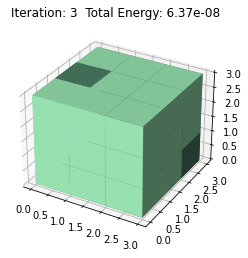

In [59]:
# Execute this block to run the entire simulation
s = time.time()
#m = main_program(iterations = 1, angle_step_size = 9, rows = 10, columns = 10, height = 10)
m = main_program(iterations = 3, angle_step_size = 10, rows = 3, columns = 3, height = 3)
e = time.time()

In [ ]:
print(e-s)

In [ ]:
######################################################

In [ ]:
# Runnning a 100x100x100 material simulation, with 5 deg step size
#   for 100+ iterations, saving the material state after each iteration 
#     and noting the time reqd for each iteration

In [ ]:
time_log_100 = list()
s1 = time.time()
m_100 = main_program(iterations = 1, angle_step_size = 5, rows = 100, columns = 100, height = 100)
e1 = time.time()
print(e1-s1)
time_log_100.append(e1-s1)
for i in range(1,102):
    s1 = time.time()
    m_100 = main_program(iterations = 1, angle_step_size = 5, rows = 100, columns = 100, height = 100, given_model = m_100)
    e1 = time.time()
    print(e1-s1)
    time_log_100.append(e1-s1)

    file_name = str('iterations=') + str(m_100[0][0]) +' step_angle_size='+ str(m_100[0][1]) + ' n_state=' + str(m_100[0][2][0]) + 'x'+ str(m_100[0][2][1]) + 'x'+ str(m_100[0][2][2]) + '.npy'
    print(file_name)
    # converting the created list-model into numpy array
    mod = np.array(m_100, dtype=object)

    np.save(file_name,mod)    # .npy extension is added if not given
    
t = np.array(time_log_100, dtype=object)
np.save('time_log_100x100x100.npy',t)